# Numeric Inference: Predicting Video Popularity from Title Embeddings

This notebook explores the predictive power of video title embeddings for estimating video views. We train per-channel linear regression models using low-dimensional semantic representations.

## 1. Setup and Configuration

Install necessary libraries and mount Google Drive.

In [1]:
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib seaborn

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sentence_transformers import SentenceTransformer

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab or drive mount failed.')

# Configuration
CONFIG = {
    'INPUT_PATH': '/content/drive/MyDrive/Graphiko/exports/base_data/latest/channels_structured_v2.json',
    'OUTPUT_DIR': '/content/drive/MyDrive/numeric_inference_outputs',
    'EMBEDDING_MODEL_NAME': 'all-MiniLM-L6-v2',
    'PCA_COMPONENTS': 15,
    'MIN_VIDEOS_PER_CHANNEL': 200,
    'REUSE_CACHE': True
}

if not os.path.exists(CONFIG['OUTPUT_DIR']):
    os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

embedding_model = SentenceTransformer(CONFIG['EMBEDDING_MODEL_NAME'])

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 2. Data Loading and Filtering

Load the structured channel data and filter for channels with at least 40 videos.

In [2]:
def load_and_filter_data(file_path):
    if not os.path.exists(file_path):
        print(f'Error: File not found at {file_path}')
        return []

    with open(file_path, 'r') as f:
        data = json.load(f)

    filtered_data = []
    total_videos_count = 0

    for channel in data:
        # Filter videos by year (2023, 2024, 2025)
        filtered_videos = [
            v for v in channel['videos']
            if any(year in v.get('publishedAt', '') for year in ['2023', '2024', '2025'])
        ]

        if len(filtered_videos) >= CONFIG['MIN_VIDEOS_PER_CHANNEL']:
            filtered_data.append({
                'channel_id': channel['channel_id'],
                'channel_name': channel['channel_name'],
                'videos': filtered_videos
            })
            total_videos_count += len(filtered_videos)

    print(f'Original channels: {len(data)}')
    print(f'Filtered channels (>= {CONFIG["MIN_VIDEOS_PER_CHANNEL"]} videos from 2023-2025): {len(filtered_data)}')
    print(f'Total videos in final dataset: {total_videos_count}')

    return filtered_data

channels = load_and_filter_data(CONFIG['INPUT_PATH'])

Original channels: 27
Filtered channels (>= 200 videos from 2023-2025): 17
Total videos in final dataset: 7044


## 3. Embedding Video Titles

Embed all video titles using the specified model. We cache embeddings to Google Drive to avoid redundant computations.

In [3]:
def get_embedding_cache_path():
    return os.path.join(CONFIG['OUTPUT_DIR'], 'video_title_embeddings_latest.json')

def load_embedding_cache():
    path = get_embedding_cache_path()
    if CONFIG['REUSE_CACHE'] and os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return {}

def save_embedding_cache(cache):
    path = get_embedding_cache_path()
    with open(path, 'w') as f:
        json.dump(cache, f)

    # Versioned copy
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    versioned_path = os.path.join(CONFIG['OUTPUT_DIR'], f'video_title_embeddings_{timestamp}.json')
    with open(versioned_path, 'w') as f:
        json.dump(cache, f)

embedding_cache = load_embedding_cache()

def embed_titles(channels_data):
    all_titles = []
    for channel in channels_data:
        for video in channel['videos']:
            if video['title'] not in embedding_cache:
                all_titles.append(video['title'])

    if all_titles:
        print(f'Embedding {len(all_titles)} new titles...')
        new_embeddings = embedding_model.encode(all_titles, show_progress_bar=True)
        for title, emb in zip(all_titles, new_embeddings):
            embedding_cache[title] = emb.tolist()
        save_embedding_cache(embedding_cache)
    else:
        print('All titles already embedded and cached.')

if channels:
    embed_titles(channels)

Embedding 6770 new titles...


Batches:   0%|          | 0/212 [00:00<?, ?it/s]

## 4. Data Splitting

Split the data into 80% training and 20% testing per channel. Save both files in Google drive, and document both paths.

In [4]:
train_data = []
test_data = []

for channel in channels:
    videos = channel['videos']
    train_vids, test_vids = train_test_split(videos, test_size=0.2, random_state=42)

    train_data.append({
        'channel_id': channel['channel_id'],
        'channel_name': channel['channel_name'],
        'videos': train_vids
    })

    test_data.append({
        'channel_id': channel['channel_id'],
        'channel_name': channel['channel_name'],
        'videos': test_vids
    })

# Save splits
train_path = os.path.join(CONFIG['OUTPUT_DIR'], 'train_structured_latest.json')
test_path = os.path.join(CONFIG['OUTPUT_DIR'], 'test_structured_latest.json')

with open(train_path, 'w') as f:
    json.dump(train_data, f, indent=2)
with open(test_path, 'w') as f:
    json.dump(test_data, f, indent=2)

# Versioned copies
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_path_train = os.path.join(CONFIG['OUTPUT_DIR'], f'train_structured_{timestamp}.json')
save_path_test = os.path.join(CONFIG['OUTPUT_DIR'], f'test_structured_{timestamp}.json')

with open(save_path_train, 'w') as f:
    json.dump(train_data, f, indent=2)
with open(save_path_test, 'w') as f:
    json.dump(test_data, f, indent=2)

print(f'Training split saved to: {train_path} (and {save_path_train})')
print(f'Testing split saved to: {test_path} (and {save_path_test})')

Training split saved to: /content/drive/MyDrive/numeric_inference_outputs/train_structured_latest.json (and /content/drive/MyDrive/numeric_inference_outputs/train_structured_20260614_212646.json)
Testing split saved to: /content/drive/MyDrive/numeric_inference_outputs/test_structured_latest.json (and /content/drive/MyDrive/numeric_inference_outputs/test_structured_20260614_212646.json)


## 5. Dimensionality Reduction (PCA)

Reduce the embedding dimensionality to 20 using PCA, fitted on the entire training set.

In [5]:
def get_all_embeddings(data_split):
    embeddings = []
    for channel in data_split:
        for video in channel['videos']:
            embeddings.append(embedding_cache[video['title']])
    return np.array(embeddings)

train_embeddings = get_all_embeddings(train_data)
test_embeddings = get_all_embeddings(test_data)

print(f'Train embeddings shape: {train_embeddings.shape}')
print(f'Test embeddings shape: {test_embeddings.shape}')

pca = PCA(n_components=CONFIG['PCA_COMPONENTS'], random_state=42)
train_pca = pca.fit_transform(train_embeddings)
test_pca = pca.transform(test_embeddings)

print(f'Train PCA shape: {train_pca.shape}')
print(f'Test PCA shape: {test_pca.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')

Train embeddings shape: (5629, 384)
Test embeddings shape: (1415, 384)
Train PCA shape: (5629, 15)
Test PCA shape: (1415, 15)
Explained variance ratio: 0.2952


## 6. Model Training: Linear Regression per Channel

Train a linear regression model for each channel to predict log-views.

In [6]:
channel_models = {}
training_summaries = []

current_train_idx = 0

for channel in train_data:
    num_videos = len(channel['videos'])
    channel_train_pca = train_pca[current_train_idx : current_train_idx + num_videos]

    # Get log views
    views = [v['views'] for v in channel['videos']]
    # Use log1p to handle zero views if any, though unlikely for filtered channels
    log_views = np.log1p(views)

    model = LinearRegression()
    model.fit(channel_train_pca, log_views)

    train_preds = model.predict(channel_train_pca)
    train_r2 = r2_score(log_views, train_preds)
    train_mae = mean_absolute_error(log_views, train_preds)

    channel_models[channel['channel_id']] = model

    training_summaries.append({
        'channel_name': channel['channel_name'],
        'num_videos': num_videos,
        'train_r2': train_r2,
        'train_mae': train_mae
    })

    current_train_idx += num_videos

df_train_summary = pd.DataFrame(training_summaries)
print('Training Summary (Top 10 Channels by R2):')
display(df_train_summary.sort_values('train_r2', ascending=False).head(10))

print(f'Mean Training R2: {df_train_summary["train_r2"].mean():.4f}')
print(f'Mean Training MAE (log scale): {df_train_summary["train_mae"].mean():.4f}')

Training Summary (Top 10 Channels by R2):


,channel_name,num_videos,train_r2,train_mae
0,The Prof G Pod – Scott Galloway,251,0.475719,0.839619
8,Greg Isenberg,233,0.466411,0.993166
11,Anthony Pompliano,526,0.465660,0.600501
7,ARK Invest,241,0.422409,0.767056
14,Peter H. Diamandis,392,0.411562,1.106947
1,Asianometry,231,0.294792,0.506555
12,20VC with Harry Stebbings,748,0.280738,1.191153
10,Alex Hormozi,176,0.262681,0.600754
3,a16z,291,0.228119,0.923191
6,All-In Podcast,230,0.228060,0.536115


Mean Training R2: 0.2693
Mean Training MAE (log scale): 0.8340


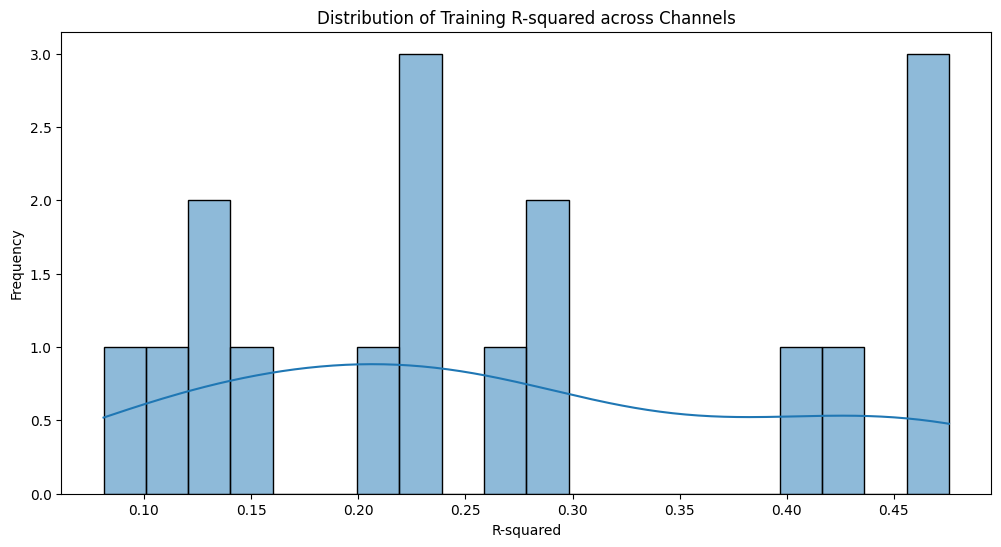

In [7]:
# Visualizing Training Performance
plt.figure(figsize=(12, 6))
sns.histplot(df_train_summary['train_r2'], bins=20, kde=True)
plt.title('Distribution of Training R-squared across Channels')
plt.xlabel('R-squared')
plt.ylabel('Frequency')
plt.show()

## 7. Prediction and Evaluation on Testing Data

Use the trained channel models to predict views for the testing videos.

In [12]:
testing_results = []
all_actual_log_views = []
all_predicted_log_views = []

current_test_idx = 0

for channel in test_data:
    channel_id = channel['channel_id']
    num_videos = len(channel['videos'])
    channel_test_pca = test_pca[current_test_idx : current_test_idx + num_videos]

    actual_views = [v['views'] for v in channel['videos']]
    actual_log_views = np.log1p(actual_views)

    model = channel_models[channel_id]
    predicted_log_views = model.predict(channel_test_pca)

    test_r2 = r2_score(actual_log_views, predicted_log_views)
    test_mae = mean_absolute_error(actual_log_views, predicted_log_views)

    testing_results.append({
        'channel_name': channel['channel_name'],
        'num_test_videos': num_videos,
        'test_r2': test_r2,
        'test_mae': test_mae
    })

    all_actual_log_views.extend(actual_log_views)
    all_predicted_log_views.extend(predicted_log_views)

    current_test_idx += num_videos

df_test_summary = pd.DataFrame(testing_results)
print('Testing Summary (Top 10 Channels by R2):')
display(df_test_summary.sort_values('test_r2', ascending=False))

global_r2 = r2_score(all_actual_log_views, all_predicted_log_views)
global_mae = mean_absolute_error(all_actual_log_views, all_predicted_log_views)

print(f'\nGlobal R2 (all test videos): {global_r2:.4f}')
print(f'Global MAE (all test videos, log scale): {global_mae:.4f}')
print(f'Mean Per-Channel Test R2: {df_test_summary["test_r2"].mean():.4f}')

Testing Summary (Top 10 Channels by R2):


,channel_name,num_test_videos,test_r2,test_mae
8,Greg Isenberg,59,0.499591,0.978196
11,Anthony Pompliano,132,0.416314,0.564568
12,20VC with Harry Stebbings,187,0.268836,1.131001
0,The Prof G Pod – Scott Galloway,63,0.264822,0.800346
9,Bloomberg Originals,132,0.263689,1.170185
14,Peter H. Diamandis,98,0.232601,1.175777
16,Tim Ferriss,86,0.191617,0.913214
5,Real Vision Presents,59,0.178376,0.725556
7,ARK Invest,61,0.116856,0.804931
3,a16z,73,0.100726,1.022452



Global R2 (all test videos): 0.6638
Global MAE (all test videos, log scale): 0.9161
Mean Per-Channel Test R2: 0.1355


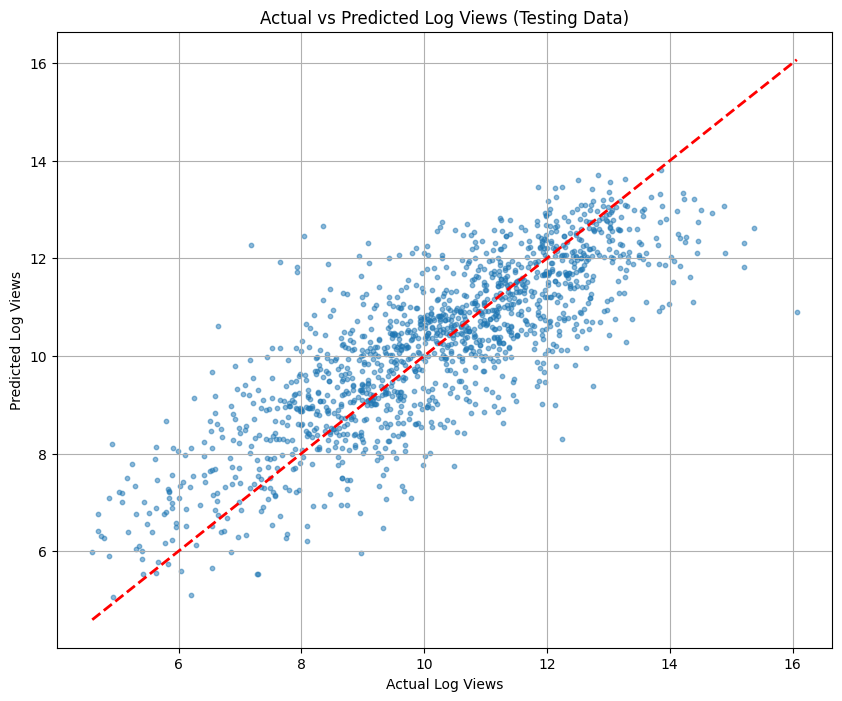

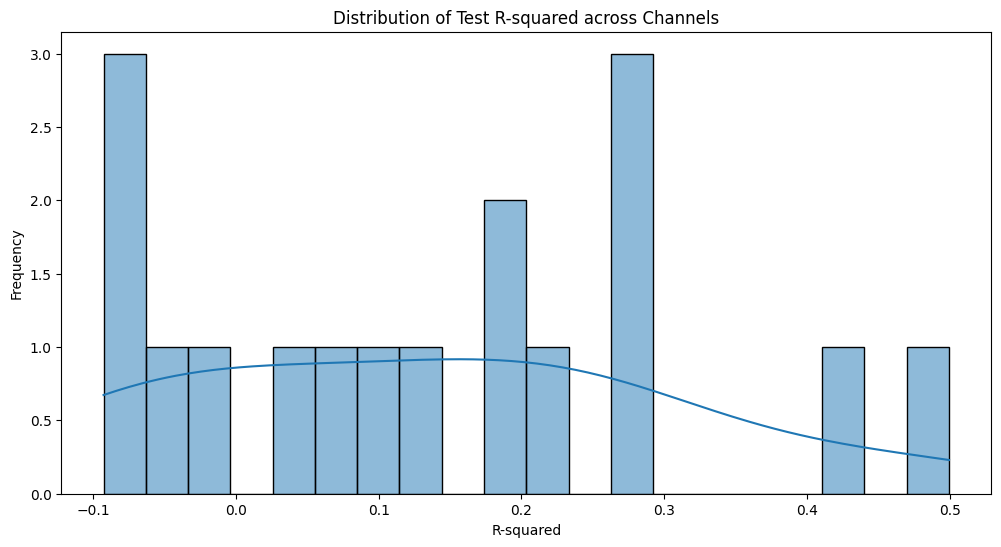

In [9]:
# Visualizing Prediction Performance
plt.figure(figsize=(10, 8))
plt.scatter(all_actual_log_views, all_predicted_log_views, alpha=0.5, s=10)
plt.plot([min(all_actual_log_views), max(all_actual_log_views)],
         [min(all_actual_log_views), max(all_actual_log_views)],
         'r--', lw=2)
plt.title('Actual vs Predicted Log Views (Testing Data)')
plt.xlabel('Actual Log Views')
plt.ylabel('Predicted Log Views')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df_test_summary['test_r2'], bins=20, kde=True)
plt.title('Distribution of Test R-squared across Channels')
plt.xlabel('R-squared')
plt.ylabel('Frequency')
plt.show()

## 8. Analysis of Predictive Value of Dimensions

Analyze how much each PCA dimension contributes to the predictions, both globally (aggregated) and by channel.

Mean Absolute Coefficient per Dimension (Global Importance):


,0
Dim_4,1.847445
Dim_10,1.437655
Dim_6,1.212424
Dim_9,1.167550
Dim_13,1.152073
Dim_3,1.150917
Dim_2,1.127822
Dim_5,1.123241
Dim_15,1.102044
Dim_1,1.062703


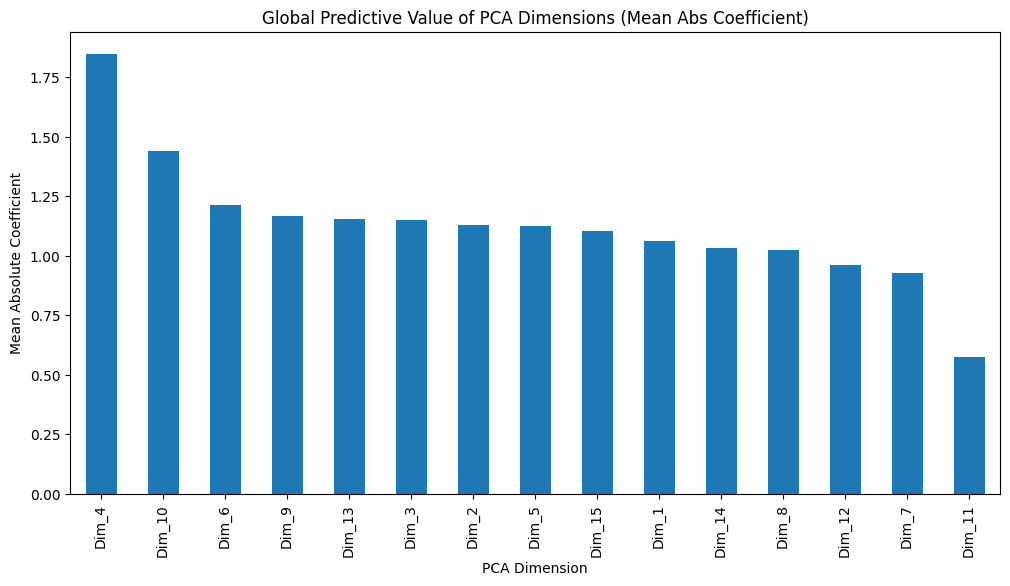

In [10]:
# Aggregating Coefficients across all channel models
all_coefficients = []
for channel_id, model in channel_models.items():
    all_coefficients.append(model.coef_)

df_coeffs = pd.DataFrame(all_coefficients, columns=[f'Dim_{i+1}' for i in range(CONFIG['PCA_COMPONENTS'])])

print('Mean Absolute Coefficient per Dimension (Global Importance):')
mean_abs_coeffs = df_coeffs.abs().mean().sort_values(ascending=False)
display(mean_abs_coeffs)

plt.figure(figsize=(12, 6))
mean_abs_coeffs.plot(kind='bar')
plt.title('Global Predictive Value of PCA Dimensions (Mean Abs Coefficient)')
plt.xlabel('PCA Dimension')
plt.ylabel('Mean Absolute Coefficient')
plt.show()

Dimension with highest coefficient for each channel (Top 10):


,channel_name,top_dimension
0,The Prof G Pod – Scott Galloway,Dim_10
1,Asianometry,Dim_15
2,Lenny's Podcast,Dim_1
3,a16z,Dim_4
4,Dan Martell,Dim_9
5,Real Vision Presents,Dim_3
6,All-In Podcast,Dim_4
7,ARK Invest,Dim_10
8,Greg Isenberg,Dim_13
9,Bloomberg Originals,Dim_10


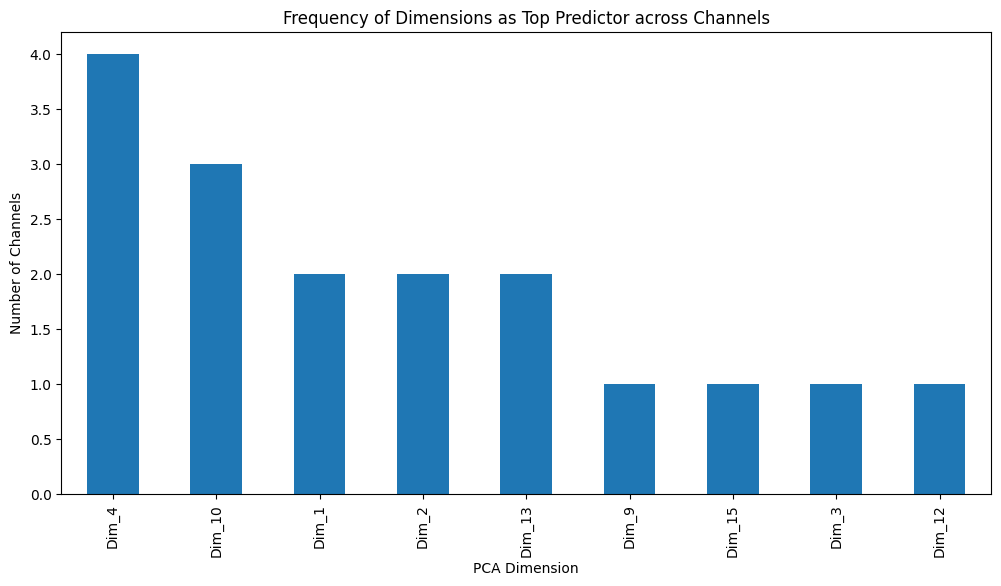

In [11]:
# Per-Channel Dimension Importance
print('Dimension with highest coefficient for each channel (Top 10):')
top_dim_per_channel = df_coeffs.idxmax(axis=1)
df_top_dims = pd.DataFrame({
    'channel_name': [c['channel_name'] for c in train_data],
    'top_dimension': top_dim_per_channel
})
display(df_top_dims.head(10))

plt.figure(figsize=(12, 6))
df_top_dims['top_dimension'].value_counts().plot(kind='bar')
plt.title('Frequency of Dimensions as Top Predictor across Channels')
plt.xlabel('PCA Dimension')
plt.ylabel('Number of Channels')
plt.show()